🔄 Loading California Housing Dataset...

🔍 Step 5: Detecting Overfitting on Baseline Decision Tree...
   • Decision Tree Train RMSE: 0.0000
   • Decision Tree Test RMSE:  0.7030
   • Performance Gap:         0.7030
   💡 Note: A massive gap indicates clear overfitting!

🛡️ Step 6: Running 5-Fold Cross-Validation...
   • Stable 5-Fold CV Mean RMSE: 0.8957

⚙️ Step 7: Starting GridSearchCV Tuning (This may take a few seconds)...
   🎉 Best Hyperparameters Found: {'max_depth': 10, 'min_samples_split': 10}

📊 Step 8 & 9: Compiling Results Summary Table...


,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


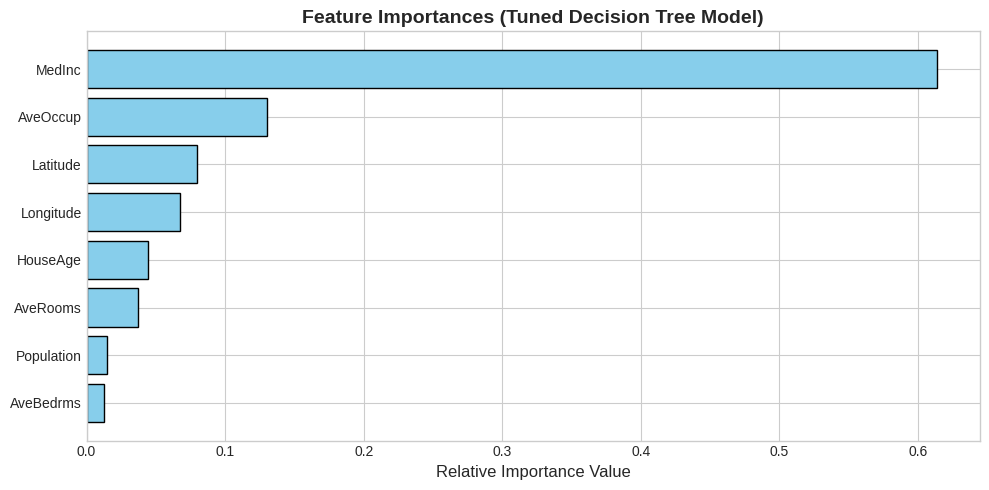

In [1]:
# ==========================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, r2_score  # Modern scikit-learn API

# Set styling for better-looking plots in Colab
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# STEP 2: LOAD AND PREPARE DATASET
# ==========================================
print("🔄 Loading California Housing Dataset...")
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# ==========================================
# STEP 3: FEATURE SCALING
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# STEP 4: TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==========================================
# STEP 5: DETECT OVERFITTING (Baseline Decision Tree)
# ==========================================
print("\n🔍 Step 5: Detecting Overfitting on Baseline Decision Tree...")
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

# Calculate RMSE using updated root_mean_squared_error function
train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(f"   • Decision Tree Train RMSE: {train_rmse:.4f}")
print(f"   • Decision Tree Test RMSE:  {test_rmse:.4f}")
print(f"   • Performance Gap:         {test_rmse - train_rmse:.4f}")
print("   💡 Note: A massive gap indicates clear overfitting!")

# ==========================================
# STEP 6: CROSS-VALIDATION (5-Fold)
# ==========================================
print("\n🛡️ Step 6: Running 5-Fold Cross-Validation...")
cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
cv_rmse = -cv_scores.mean()
print(f"   • Stable 5-Fold CV Mean RMSE: {cv_rmse:.4f}")

# ==========================================
# STEP 7: HYPERPARAMETER TUNING VIA GRIDSEARCHCV
# ==========================================
print("\n⚙️ Step 7: Starting GridSearchCV Tuning (This may take a few seconds)...")
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
grid.fit(X_train, y_train)

print(f"   🎉 Best Hyperparameters Found: {grid.best_params_}")

# ==========================================
# STEP 8 & 9: EVALUATE OPTIMIZED MODEL & COMPARE
# ==========================================
print("\n📊 Step 8 & 9: Compiling Results Summary Table...")
best_tree = grid.best_estimator_
y_pred_tree = best_tree.predict(X_test)

tuned_rmse = root_mean_squared_error(y_test, y_pred_tree)
tuned_r2 = r2_score(y_test, y_pred_tree)

# Baseline models logic for structural comparison
lr = LinearRegression().fit(X_train, y_train)
lr_rmse = root_mean_squared_error(y_test, lr.predict(X_test))
lr_r2 = r2_score(y_test, lr.predict(X_test))

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
ridge_rmse = root_mean_squared_error(y_test, ridge.predict(X_test))
ridge_r2 = r2_score(y_test, ridge.predict(X_test))

# Create final DataFrame summary
results = {
    "Model": ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE": [lr_rmse, ridge_rmse, tuned_rmse],
    "R2 Score": [lr_r2, ridge_r2, tuned_r2]
}
results_df = pd.DataFrame(results)

# Return the styled dataframe directly so Google Colab renders it as a pretty table
display(results_df)

# ==========================================
# OPTIONAL VISUALIZATION (Task Deliverable Extra)
# ==========================================
plt.figure(figsize=(10, 5))
importances = best_tree.feature_importances_
indices = np.argsort(importances)
plt.title('Feature Importances (Tuned Decision Tree Model)', fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='skyblue', edgecolor='black')
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.xlabel('Relative Importance Value', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=300) # Saves the plot in your Colab files
plt.show()